 EDA para o Problema da Minerva

## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


import matplotlib.cm as cm
import matplotlib.colors as mcolors

import statsmodels.api as sm
import numpy as np
import pandas as pd


In [2]:
# ---------------------------------------------------------
# CONFIGURAÇÃO DO DIRETÓRIO RAIZ
# ---------------------------------------------------------
# Verifica se a pasta 'data' existe no diretório atual. 
# Se não existir, ele assume que estamos na pasta 'notebook' e sobe um nível ('..')
if not os.path.isdir('data'):
    os.chdir('..')

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")

Diretório de trabalho atualizado para: /Users/ngodeny/Documents/mestrado/2026-resolucao_problemas/2026_resolucao_problemas


In [3]:
file_path = 'data/raw/instance_desafio_minerva.xlsx'

## Leitura dos dados

In [4]:
df = pd.read_excel(file_path, sheet_name='base_dados')

In [5]:
df.head()

,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$)
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805


In [6]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Produto                 86 non-null     str           
 1   Data                    86 non-null     datetime64[us]
 2   Volume Realizado (kg)   86 non-null     float64       
 3   Receita Realizada (R$)  86 non-null     float64       
 4   Custo Realizado (R$)    86 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 3.5 KB


None

In [7]:
# 1. Garantir que a Data é do tipo datetime
df['Data'] = pd.to_datetime(df['Data'])

# 2. Extrair o Dia da Semana e mapear para nomes
dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 
            4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['Dia da Semana'] = df['Data'].dt.dayofweek.map(dias_map)

# 3. Calcular Variáveis Unitárias
df['Preço'] = df['Receita Realizada (R$)'] / df['Volume Realizado (kg)']
df['Custo Realizado (R$/kg)'] = df['Custo Realizado (R$)'] / df['Volume Realizado (kg)']

# Visualização inicial para confirmar
display(df.head())

,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$),Dia da Semana,Preço,Custo Realizado (R$/kg)
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571,Sexta,1267.949227,983.791250
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770,Segunda,1279.335771,984.906501
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598,Terça,1258.408986,985.657521
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597,Quarta,1241.133798,984.567075
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805,Quinta,1253.118993,987.177524


## Separar em teste e treino
- Definido por regra que o treino é até dia 31/10/2025 (inclusive)

In [8]:
data_corte = pd.to_datetime('2025-10-31')

# Treino: Dados até 31/10/2025 (inclusive)
df_treino_raw = df[df['Data'] <= data_corte].copy()

# Teste: Dados a partir de 01/11/2025
df_teste_raw = df[df['Data'] > data_corte].copy()

print(f"Período de Treino: {df_treino_raw['Data'].min().date()} até {df_treino_raw['Data'].max().date()}")
print(f"Período de Teste: {df_teste_raw['Data'].min().date()} até {df_teste_raw['Data'].max().date()}\n")

print(f"Tamanho da base de Treino: {df_treino_raw.shape[0]} dias")
print(f"Tamanho da base de Teste: {df_teste_raw.shape[0]} dias")

Período de Treino: 2025-08-01 até 2025-10-31
Período de Teste: 2025-11-03 até 2025-11-14

Tamanho da base de Treino: 76 dias
Tamanho da base de Teste: 10 dias


### Salvar split

In [9]:
caminho_interim = 'data/interim/'
caminho_teste = caminho_interim + '.teste.csv'
caminho_treino = caminho_interim + '.treino.csv'

In [10]:
df_treino_raw.to_csv(caminho_treino, index=False)
df_teste_raw.to_csv(caminho_teste, index=False)


# Descritiva

## Estatística Descritiva (Treino)

In [11]:
# ler treino do interim e trata data como datetipe
df_treino = pd.read_csv(caminho_treino, parse_dates=['Data'])

In [12]:
# Cálculo da Margem (Receita - Custo)
df_treino['Margem'] = df_treino['Receita Realizada (R$)'] - df_treino['Custo Realizado (R$)']

# Seleção das colunas numéricas de interesse
cols_analise = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem']

# Geração da tabela descritiva (transposta para melhor visualização)
descritiva = df_treino[cols_analise].describe().T
descritiva['Coef_Variacao (%)'] = (descritiva['std'] / descritiva['mean']) * 100

print("Estatística Descritiva (Base de Treino Oficial - Até 31/10/2025):")
display(descritiva.round(2))

Estatística Descritiva (Base de Treino Oficial - Até 31/10/2025):


,count,mean,std,min,25%,50%,75%,max,Coef_Variacao (%)
Volume Realizado (kg),76.0,21.13,18.94,0.59,7.60,16.70,28.45,100.00,89.65
Preço,76.0,1275.02,39.23,1188.86,1245.92,1276.49,1298.94,1365.49,3.08
Custo Realizado (R$/kg),76.0,981.63,12.96,949.12,973.95,983.67,986.24,1030.34,1.32
Margem,76.0,5862.31,4526.00,123.89,2107.49,5280.24,8061.05,21571.06,77.21


## Teste de hipóteses

In [13]:
# 1. Isolando apenas os dias úteis na base de treino
df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])].copy()

# 2. Transformação Logarítmica (Para a Curva de Elasticidade Log-Log)
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# 3. Criando Variáveis de Sazonalidade
df_uteis['Dia do Mês'] = df_uteis['Data'].dt.day

# -- Quinzena
df_uteis['Quinzena'] = np.where(df_uteis['Dia do Mês'] <= 15, '1ª Quinzena', '2ª Quinzena')

# -- Mês
mapa_meses = {8: 'Agosto', 9: 'Setembro', 10: 'Outubro'}
df_uteis['Mês'] = df_uteis['Data'].dt.month.map(mapa_meses)

# -- Semana do Mês (Lógica: dias 1-7=Sem1, 8-14=Sem2...)
df_uteis['Semana do Mês'] = (df_uteis['Dia do Mês'] - 1) // 7 + 1

print("Feature Engineering concluído com sucesso!")
df_uteis.head()

Feature Engineering concluído com sucesso!


,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$),Dia da Semana,Preço,Custo Realizado (R$/kg),Margem,ln_Volume,ln_Preco,Dia do Mês,Quinzena,Mês,Semana do Mês
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571,Sexta,1267.949227,983.791250,1598.569081,1.727334,7.145156,1,1ª Quinzena,Agosto,1
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770,Segunda,1279.335771,984.906501,9242.270435,3.446504,7.154096,4,1ª Quinzena,Agosto,1
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598,Terça,1258.408986,985.657521,6050.960677,3.099411,7.137603,5,1ª Quinzena,Agosto,1
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597,Quarta,1241.133798,984.567075,2830.134679,2.400691,7.123781,6,1ª Quinzena,Agosto,1
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805,Quinta,1253.118993,987.177524,4031.886717,2.718713,7.133391,7,1ª Quinzena,Agosto,1


### Semana

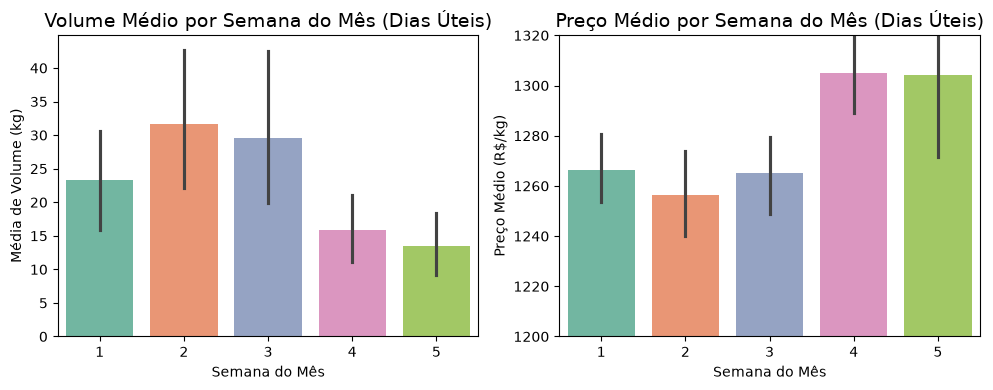

In [14]:
# 2. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Gráfico da Esquerda: Volume
sns.barplot(data=df_uteis, x='Semana do Mês', y='Volume Realizado (kg)', 
            ax=axes[0], palette='Set2', hue='Semana do Mês', legend=False)
axes[0].set_title('Volume Médio por Semana do Mês (Dias Úteis)', fontsize=14)
axes[0].set_ylabel('Média de Volume (kg)')

# Gráfico da Direita: Preço
sns.barplot(data=df_uteis, x='Semana do Mês', y='Preço', 
            ax=axes[1], palette='Set2', hue='Semana do Mês', legend=False)
axes[1].set_title('Preço Médio por Semana do Mês (Dias Úteis)', fontsize=14)
axes[1].set_ylabel('Preço Médio (R$/kg)')
axes[1].set_ylim(1200, 1320)

plt.tight_layout()
plt.show()


In [15]:

# 3. Prova Matemática (P-valor da Semana do Mês)
# Como são 5 semanas no mês, o Python usa a 'Semana 1' como base (const) e testa as outras 4.
dummies_semana = pd.get_dummies(df_uteis['Semana do Mês'], drop_first=True, prefix='Semana', dtype=int)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

X_semana = df_uteis[['ln_Preco']].join([dummies_semana, dummies_dia])
X_semana = sm.add_constant(X_semana)
y = df_uteis['ln_Volume']

modelo_semana = sm.OLS(y, X_semana).fit()

print("=== Relevância da SEMANA DO MÊS ===")
print("Categoria Base (const): Semana 1 e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_semana.summary().tables[1])

=== Relevância da SEMANA DO MÊS ===
Categoria Base (const): Semana 1 e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.1348     15.080      6.972      0.000      74.925     135.344
ln_Preco     -14.2844      2.111     -6.766      0.000     -18.513     -10.055
Semana_2       0.2367      0.162      1.466      0.148      -0.087       0.560
Semana_3       0.2057      0.161      1.280      0.206      -0.116       0.528
Semana_4       0.0351      0.173      0.203      0.840      -0.311       0.381
Semana_5       0.2274      0.222      1.023      0.311      -0.218       0.673
Quinta        -0.0511      0.173     -0.296      0.768      -0.397       0.295
Segunda        0.3138      0.173      1.818      0.074      -0.032       0.660

### Quinzena

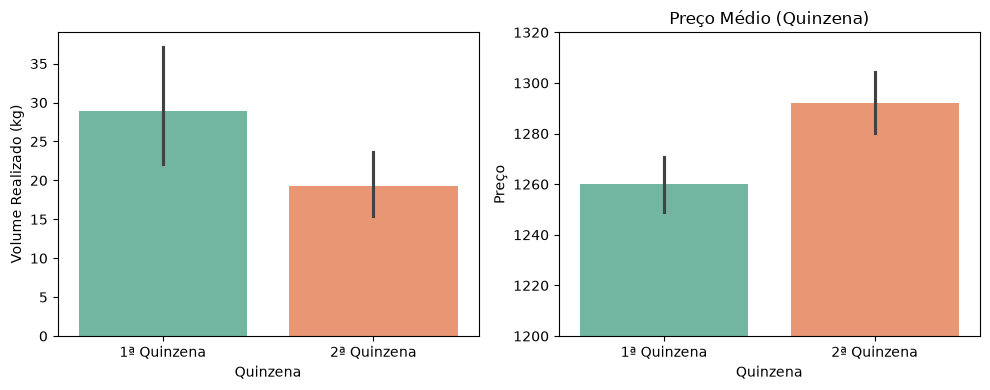

In [16]:
# 1. Gráficos
ordem_quinzena = ['1ª Quinzena', '2ª Quinzena']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=df_uteis, x='Quinzena', y='Volume Realizado (kg)', order=ordem_quinzena, ax=axes[0], palette='Set2',
            hue='Quinzena', legend=False)

sns.barplot(data=df_uteis, x='Quinzena', y='Preço', order=ordem_quinzena, ax=axes[1], palette='Set2',
            hue='Quinzena', legend=False)
axes[1].set_title('Preço Médio (Quinzena)', fontsize=12)
axes[1].set_ylim(1200, 1320)

plt.tight_layout()
plt.show()

In [17]:
# 4. Prova Matemática (Teste Isolado para a Quinzena)
# Transformação Log-Log (Garantindo que as colunas existam)
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# Criando as Dummies da Quinzena (A base 'const' será 1ª Quinzena)
dummies_quinzena = pd.get_dummies(df_uteis['Quinzena'], drop_first=True, dtype=int)
# Criando as Dummies do Dia (A base 'const' será Quarta-feira)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

# Juntando: Preço + Quinzena + Dia da Semana
X_quinzena = df_uteis[['ln_Preco']].join([dummies_quinzena, dummies_dia])
X_quinzena = sm.add_constant(X_quinzena)
y = df_uteis['ln_Volume']

# Ajustando o modelo
modelo_quinzena = sm.OLS(y, X_quinzena).fit()

print("=== Relevância da QUINZENA ===")
print("Categoria Base (const): 1ª Quinzena e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_quinzena.summary().tables[1])

=== Relevância da QUINZENA ===
Categoria Base (const): 1ª Quinzena e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         112.8260     14.197      7.947      0.000      84.418     141.234
ln_Preco      -15.3459      1.989     -7.716      0.000     -19.325     -11.367
2ª Quinzena     0.0582      0.120      0.485      0.629      -0.182       0.298
Quinta         -0.0554      0.173     -0.320      0.750      -0.402       0.291
Segunda         0.3167      0.173      1.831      0.072      -0.029       0.663
Sexta          -1.2882      0.170     -7.582      0.000      -1.628      -0.948
Terça          -0.0353      0.173     -0.204      0.839      -0.382       0.311


### Mês

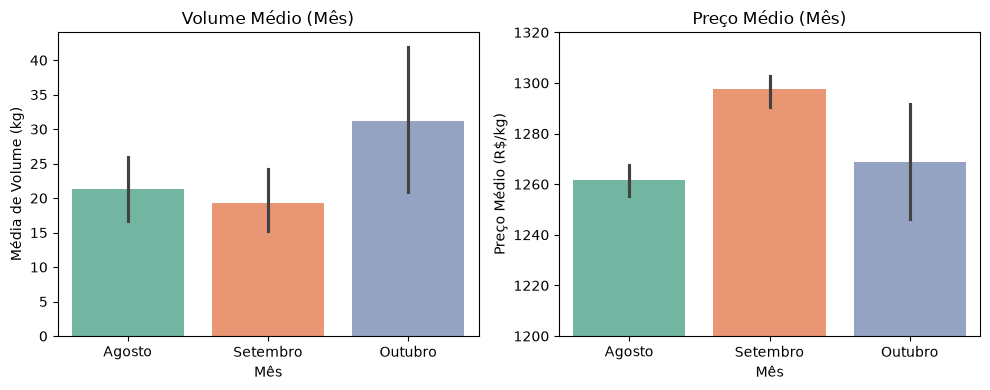

In [18]:
# 1. Configurando a ordem dos meses para o gráfico fazer sentido cronológico
ordem_meses = ['Agosto', 'Setembro', 'Outubro']

# 2. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Gráfico da Esquerda: Volume Médio por Mês
sns.barplot(data=df_uteis, x='Mês', y='Volume Realizado (kg)', 
            order=ordem_meses, ax=axes[0], palette='Set2',
            hue='Mês', legend=False)
axes[0].set_title('Volume Médio (Mês)', fontsize=12)
axes[0].set_ylabel('Média de Volume (kg)')
axes[0].set_xlabel('Mês')

# Gráfico da Direita: Preço Médio por Mês
sns.barplot(data=df_uteis, x='Mês', y='Preço', 
            order=ordem_meses, ax=axes[1], palette='Set2',
            hue='Mês', legend=False)
axes[1].set_title('Preço Médio (Mês)', fontsize=12)
axes[1].set_ylabel('Preço Médio (R$/kg)')
axes[1].set_xlabel('Mês')
axes[1].set_ylim(1200, 1320) # Cortando o eixo Y para evidenciar a diferença de preço

plt.tight_layout()
plt.show()


In [19]:

# 3. Prova Estatística (Teste Isolado para o Mês)
# Garantindo as variáveis logarítmicas
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# Criando as Dummies do Mês (A base 'const' será Agosto) e Dia da Semana
dummies_mes = pd.get_dummies(df_uteis['Mês'], drop_first=True, dtype=int)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

# Juntando: Preço + Mês + Dia da Semana
X_mes = df_uteis[['ln_Preco']].join([dummies_mes, dummies_dia])
X_mes = sm.add_constant(X_mes)
y = df_uteis['ln_Volume']

# Ajustando o modelo
modelo_mes = sm.OLS(y, X_mes).fit()

print("=== Relevância do MÊS ===")
print("Categoria Base (const): Agosto e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_mes.summary().tables[1])

=== Relevância do MÊS ===
Categoria Base (const): Agosto e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.6866     13.953      8.363      0.000      88.758     144.616
ln_Preco     -15.8997      1.954     -8.137      0.000     -19.811     -11.988
Outubro        0.1564      0.132      1.183      0.242      -0.108       0.421
Setembro       0.2132      0.144      1.477      0.145      -0.076       0.502
Quinta        -0.0509      0.171     -0.297      0.767      -0.394       0.292
Segunda        0.3139      0.172      1.830      0.072      -0.029       0.657
Sexta         -1.2773      0.168     -7.593      0.000      -1.614      -0.941
Terça         -0.0341      0.171     -0.199      0.843      -0.377       0.309


## Teste Para dias da semana

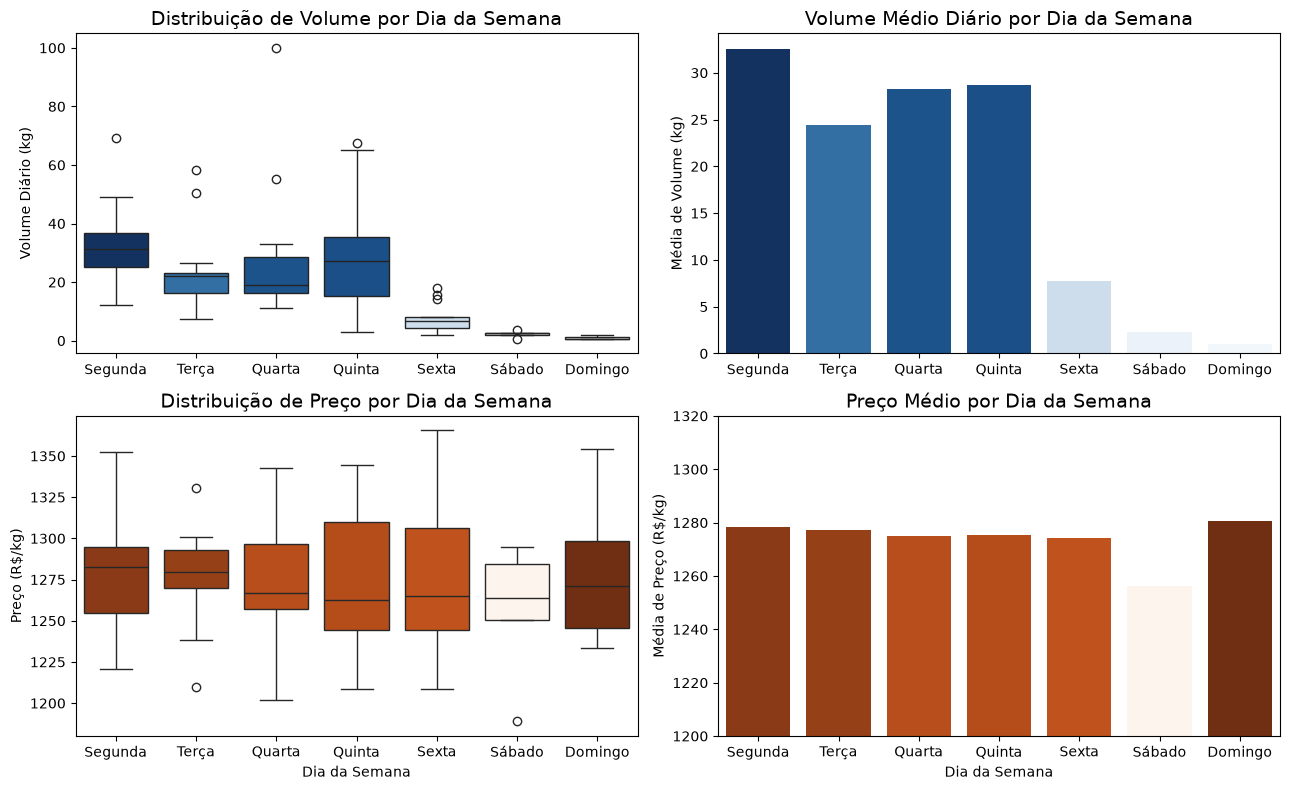

In [20]:
# 1. Ordenando os dias para o eixo X do gráfico fazer sentido
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# 2. Calculando as médias por dia (Volume e Preço)
medias_vol = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].mean()
medias_preco = df_treino.groupby('Dia da Semana')['Preço'].mean()

# 3. Criando normalizadores e dicionários de cores dinâmicas (Estilo Heatmap)
# --- Paleta do Volume (Azul) ---
norm_vol = mcolors.Normalize(vmin=0, vmax=medias_vol.max())
cmap_vol = plt.get_cmap('Blues') 
paleta_vol = {dia: cmap_vol(norm_vol(medias_vol[dia])) for dia in ordem_dias}

# --- Paleta do Preço (Laranja) ---
norm_preco = mcolors.Normalize(vmin=medias_preco.min(), vmax=medias_preco.max())
cmap_preco = plt.get_cmap('Oranges') 
paleta_preco = {dia: cmap_preco(norm_preco(medias_preco[dia])) for dia in ordem_dias}

# 4. Criando a matriz de gráficos (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ==========================================
# LINHA 0 (CIMA): GRÁFICOS DE VOLUME
# ==========================================
# Boxplot Volume
sns.boxplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[0, 0], palette=paleta_vol, hue='Dia da Semana', legend=False)
axes[0, 0].set_title("Distribuição de Volume por Dia da Semana", fontsize=14)
axes[0, 0].set_xlabel("") # Esconde o X label para não poluir
axes[0, 0].set_ylabel("Volume Diário (kg)")

# Barplot Volume
sns.barplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[0, 1], errorbar=None, palette=paleta_vol, hue='Dia da Semana', legend=False)
axes[0, 1].set_title("Volume Médio Diário por Dia da Semana", fontsize=14)
axes[0, 1].set_xlabel("") # Esconde o X label para não poluir
axes[0, 1].set_ylabel("Média de Volume (kg)")


# ==========================================
# LINHA 1 (BAIXO): GRÁFICOS DE PREÇO
# ==========================================
# Boxplot Preço
sns.boxplot(data=df_treino, x='Dia da Semana', y='Preço', 
            order=ordem_dias, ax=axes[1, 0], palette=paleta_preco, hue='Dia da Semana', legend=False)
axes[1, 0].set_title("Distribuição de Preço por Dia da Semana", fontsize=14)
axes[1, 0].set_xlabel("Dia da Semana")
axes[1, 0].set_ylabel("Preço (R$/kg)")

# Barplot Preço
sns.barplot(data=df_treino, x='Dia da Semana', y='Preço', 
            order=ordem_dias, ax=axes[1, 1], errorbar=None, palette=paleta_preco, hue='Dia da Semana', legend=False)
axes[1, 1].set_title("Preço Médio por Dia da Semana", fontsize=14)
axes[1, 1].set_xlabel("Dia da Semana")
axes[1, 1].set_ylabel("Média de Preço (R$/kg)")
axes[1, 1].set_ylim(1200, 1320) # Dá "zoom" na variação

# Ajusta o espaçamento entre os subplots e exibe
plt.tight_layout()
plt.show()

### analise do boxplot e de barras
- segunda é o dia com maior volume médio e maior mediana, boxplot razoavelmente comportado (caixa pequena)
    possivel sensibilidade menor a preços altos
- quarta é o terceior maior volume, mas mediana menor que terça, com um grande outlier em 100 que puxou a media.
    dia complicado para usar somente a media na modelagem
- quinta segue com o segundo volume médio, porem caixa longa , bigodes muito extremos variando de quase 0 até 60
    fica um dia dia muito volatil, talvez mais impactado por fatores externos
- de sexta em diante o volume despenca, distribuicao mais comportada do boxplot
    baixar preço nesse periodo pode ser um erro (cliente nao compra naturalmente)

    
Pensando na Modelagem:Ao desenhar as curvas de elasticidade $Volume = A \cdot \text{Preço}^{-B}$ penso que as evidenciass visuais  indicam que será necessario pelo menos três comportamentos distintos:
- Segunda e Quinta: Dias de alta tração (podem suportar preços marginalmente maiores se o volume já estiver garantido).
- Terça e Quarta: Dias de tração média/estável (onde a sensibilidade ao preço deve ditar o volume).
- Sexta a Domingo: Dias de baixa, indicam que grandes mudanças do preço não trarão maior volume.

### Heatmap geral

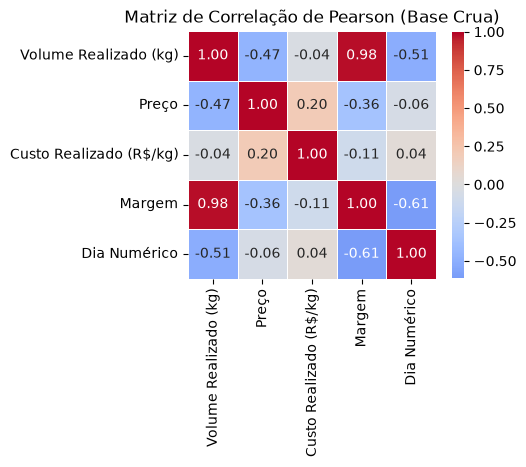

In [21]:
# Criando uma coluna numérica para o dia da semana para usar na correlação
df_treino['Dia Numérico'] = df_treino['Data'].dt.dayofweek

cols_corr = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem', 'Dia Numérico']
matriz_corr = df_treino[cols_corr].corr()

plt.figure(figsize=(4,4))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação de Pearson (Base Crua)", fontsize=12)
plt.show()

### Heatmap da correlação
- volume x preço com -0.47 (preço sobe, demanda cai), mas nao é absoluta
- volume x dia da semana = -0,51 (dia maior, menor volume)
- volume x margem = 0,98 (volume sobe, margem sobe) -> aumentar preço nao faz necessariamente a margem aumentar


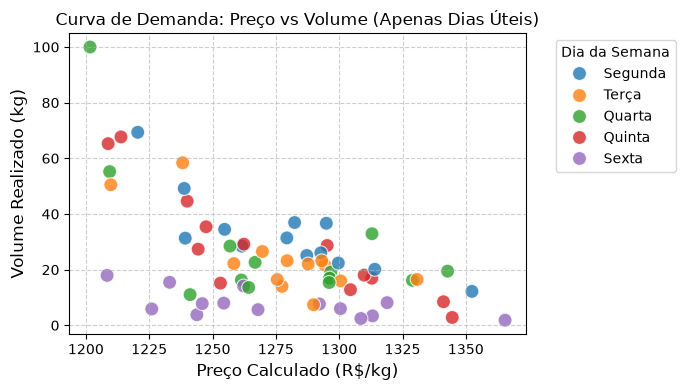

In [22]:
# Isolando apenas os dias úteis (Segunda a Sexta) usando o dia numérico
df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])]

plt.figure(figsize=(7, 4))

# Scatterplot: Alteramos o hue para 'Dia da Semana'
sns.scatterplot(data=df_uteis, x='Preço', y='Volume Realizado (kg)', 
                hue='Dia da Semana', hue_order=['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'], 
                palette="tab10", s=100, alpha=0.8)

plt.title("Curva de Demanda: Preço vs Volume (Apenas Dias Úteis)", fontsize=12)
plt.xlabel("Preço Calculado (R$/kg)", fontsize=12)
plt.ylabel("Volume Realizado (kg)", fontsize=12)
plt.legend(title="Dia da Semana", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Outliers

In [23]:
# 1. Calculando os limites matemáticos do Boxplot (IQR)
Q1 = df_uteis['Volume Realizado (kg)'].quantile(0.25)
Q3 = df_uteis['Volume Realizado (kg)'].quantile(0.75)
IQR = Q3 - Q1

# Definindo o teto (fim do bigode superior)
limite_superior = Q3 + 1.5 * IQR

print(f"Teto matemático calculado: {limite_superior:.2f} kg")

# 2. Aplicando o Capping (Tudo que for maior que o limite vira o limite)
df_treino['Volume Tratado (kg)'] = np.where(
    df_treino['Volume Realizado (kg)'] > limite_superior, 
    limite_superior, 
    df_treino['Volume Realizado (kg)']
)

# 3. Comparando as médias Antes e Depois
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
comparativo = df_treino.groupby('Dia da Semana')[['Volume Realizado (kg)', 'Volume Tratado (kg)']].mean().reindex(ordem_dias)

# Criando uma coluna de variação para ver o impacto da limpeza
comparativo['Queda após limpeza (%)'] = ((comparativo['Volume Tratado (kg)'] / comparativo['Volume Realizado (kg)']) - 1) * 100

print("\n=== Impacto do Tratamento de Outliers nas Médias ===")
display(comparativo.round(2))

Teto matemático calculado: 53.10 kg

=== Impacto do Tratamento de Outliers nas Médias ===


,Volume Realizado (kg),Volume Tratado (kg),Queda após limpeza (%)
Dia da Semana,,,
Segunda,32.58,31.33,-3.84
Terça,24.45,24.05,-1.66
Quarta,28.25,24.48,-13.35
Quinta,28.64,26.59,-7.18
Sexta,7.72,7.72,0.00
Sábado,2.26,2.26,0.00
Domingo,1.04,1.04,0.00


In [24]:
# 1. Função para calcular o limite do Boxplot e aplicar o Capping
def trata_outliers_por_grupo(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    # Substitui os valores acima do limite pelo próprio limite
    return np.clip(serie, a_min=None, a_max=limite_superior)

# 2. Aplicando a função dia a dia
df_treino['Volume Tratado (kg)'] = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].transform(trata_outliers_por_grupo)

# 3. Imprimindo os limites calculados para cada dia 
limites_calculados = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].apply(
    lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25))
)
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
print("=== Tetos Matemáticos Calculados (kg) ===")
print(limites_calculados.reindex(ordem_dias).round(2))
print("-" * 40)

# 4. Comparativo de Médias: Suja vs Limpa
comparativo_dias = df_treino.groupby('Dia da Semana')[['Volume Realizado (kg)', 'Volume Tratado (kg)']].mean().reindex(ordem_dias)
comparativo_dias['Queda após limpeza (%)'] = ((comparativo_dias['Volume Tratado (kg)'] / comparativo_dias['Volume Realizado (kg)']) - 1) * 100

print("\n=== Impacto do Tratamento nas Médias ===")
display(comparativo_dias.round(2))

=== Tetos Matemáticos Calculados (kg) ===
Dia da Semana
Segunda    54.02
Terça      33.37
Quarta     46.94
Quinta     65.75
Sexta      13.89
Sábado      3.37
Domingo     2.46
Name: Volume Realizado (kg), dtype: float64
----------------------------------------

=== Impacto do Tratamento nas Médias ===


,Volume Realizado (kg),Volume Tratado (kg),Queda após limpeza (%)
Dia da Semana,,,
Segunda,32.58,31.40,-3.62
Terça,24.45,21.21,-13.26
Quarta,28.25,23.53,-16.70
Quinta,28.64,28.49,-0.52
Sexta,7.72,7.30,-5.41
Sábado,2.26,2.19,-2.82
Domingo,1.04,1.04,0.00


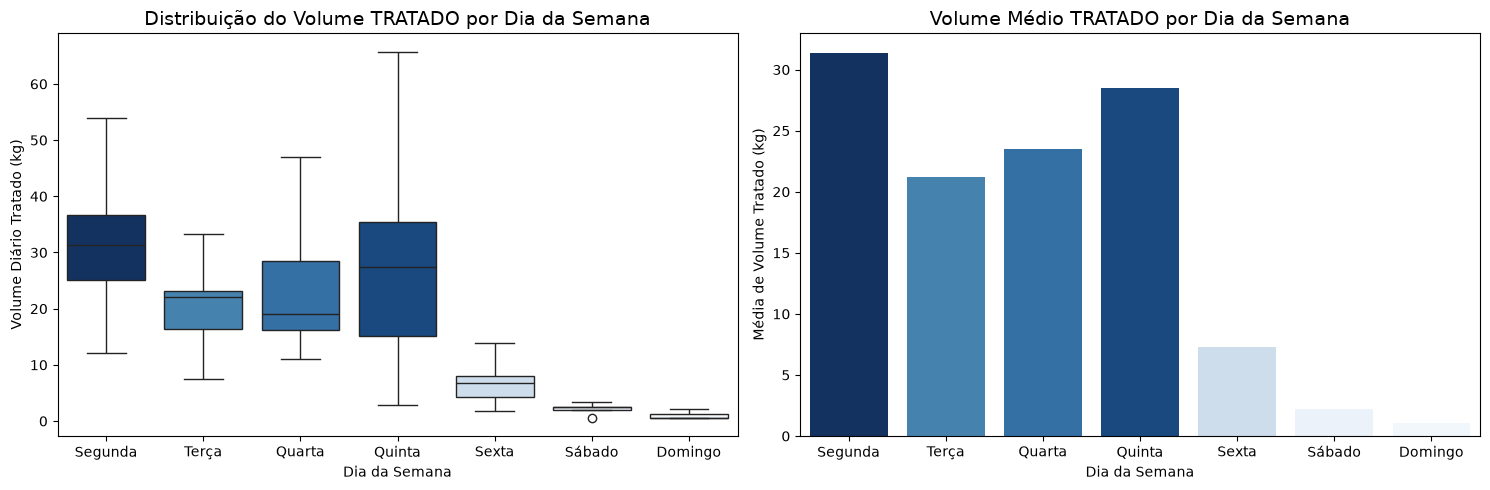

In [25]:
# 1. Definindo apenas os dias úteis na ordem correta
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# 2. Calculando a nova média tratada para o mapa de cores
medias_tratadas = df_treino.groupby('Dia da Semana')['Volume Tratado (kg)'].mean()

# 3. Criando o dicionário de cores dinâmicas (Tons de Azul)
norm_tratado = mcolors.Normalize(vmin=0, vmax=medias_tratadas.max())
cmap_tratado = plt.get_cmap('Blues') 
paleta_tratada = {dia: cmap_tratado(norm_tratado(medias_tratadas[dia])) for dia in ordem_dias}

# 4. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Boxplot: Distribuição Tratada ---
sns.boxplot(data=df_treino, x='Dia da Semana', y='Volume Tratado (kg)', 
            order=ordem_dias, ax=axes[0], palette=paleta_tratada, hue='Dia da Semana', legend=False)
axes[0].set_title("Distribuição do Volume TRATADO por Dia da Semana", fontsize=14)
axes[0].set_xlabel("Dia da Semana")
axes[0].set_ylabel("Volume Diário Tratado (kg)")

# --- Barplot: Média Tratada ---
sns.barplot(data=df_treino, x='Dia da Semana', y='Volume Tratado (kg)', 
            order=ordem_dias, ax=axes[1], errorbar=None, palette=paleta_tratada, hue='Dia da Semana', legend=False)
axes[1].set_title("Volume Médio TRATADO por Dia da Semana", fontsize=14)
axes[1].set_xlabel("Dia da Semana")
axes[1].set_ylabel("Média de Volume Tratado (kg)")

plt.tight_layout()
plt.show()

In [26]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. Isolando os dias úteis para o modelo B2B
df_uteis = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()

# 2. Transformação Log-Log usando o Dado Limpo!
df_uteis['ln_Volume_Tratado'] = np.log(df_uteis['Volume Tratado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# 3. Mapeando os Clusters definidos no EDA
def agrupar_clusters(dia):
    if dia in ['Segunda', 'Quinta']:
        return 'Cluster 1 (Pico)'
    elif dia in ['Terça', 'Quarta']:
        return 'Cluster 2 (Regular)'
    else:
        return 'Cluster 3 (Fraco)' # Sexta-feira

df_uteis['Cluster'] = df_uteis['Dia da Semana'].apply(agrupar_clusters)

# 4. Criando Dummies SEM exclusão automática
dummies_cluster = pd.get_dummies(df_uteis['Cluster'], dtype=int)

# 5. Excluindo MANUALMENTE o Cluster 2 para forçá-lo a ser a Categoria Base (const)
dummies_cluster = dummies_cluster.drop('Cluster 2 (Regular)', axis=1)

# 6. Montando a Regressão
X_final = df_uteis[['ln_Preco']].join(dummies_cluster)
X_final = sm.add_constant(X_final)
y_final = df_uteis['ln_Volume_Tratado']

modelo_final = sm.OLS(y_final, X_final).fit()

print("=== MODELO DEFINITIVO DE ELASTICIDADE ===")
print("Variável Alvo: ln_Volume_Tratado")
print("Categoria Base (const): Cluster 2 (Regular - Ter/Qua)")
print("-" * 65)
print(modelo_final.summary().tables[1])

=== MODELO DEFINITIVO DE ELASTICIDADE ===
Variável Alvo: ln_Volume_Tratado
Categoria Base (const): Cluster 2 (Regular - Ter/Qua)
-----------------------------------------------------------------
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                94.5427     12.429      7.607      0.000      69.698     119.387
ln_Preco            -12.7978      1.738     -7.364      0.000     -16.272      -9.324
Cluster 1 (Pico)      0.2094      0.118      1.778      0.080      -0.026       0.445
Cluster 3 (Fraco)    -1.2208      0.141     -8.669      0.000      -1.502      -0.939


# Salvar dados

In [27]:
# Salvando a base tratada para a etapa de Modelagem
caminho_processed = 'data/processed/treino_tratado_clusters.csv'
df_treino.to_csv(caminho_processed, index=False)
print("EDA concluído! Dados limpos exportados com sucesso.")

EDA concluído! Dados limpos exportados com sucesso.
